In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from tqdm import tqdm

global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

import src.utils.utils as utils
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [31]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H = Y.shape[-1]
Y = Y.to(torch.float32)
Y = Y.unsqueeze(0)
Y_init = Y

if dataset == "urban4":
    with open(f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

else:
    with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [32]:
n_features  = 1
use_cls     = False
extend_cls  = False
fm_name     = "DOFA"
n_features  = 4 if fm_name == "HyperSIGMA" else n_features
patch_size  = 16

if fm_name == "DOFA":
    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
        new_H = 224
    else:
        new_H = 224
    Y = Y[:,:,:224, :224]
    fm = rsfm.create_fm(fm_name, Y, n_features=n_features, use_cls=use_cls, extend_cls=extend_cls, path=global_path)
    features = rsfm.get_dofa_features(fm, Y, wavelengths)
    if use_cls:
        D = features.shape[-1]
    else:
        D = int(features.shape[0]/n_features)
        
elif fm_name == "HyperFree":
    n_features = 1
    use_cls = False
    n_patches = H//patch_size
    if n_patches%2 != 0:
        H = (n_patches-1)*patch_size + patch_size-1
    new_H = H
    Y = Y[:, :, :new_H, :new_H]
    fm = rsfm.create_fm(fm_name, Y, patch_size=patch_size, path=global_path)
    features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
    D = features.shape[0]

elif fm_name == "HyperSIGMA":
    fm = rsfm.create_fm(fm_name, Y, c, path=global_path)
    features = rsfm.get_hypersigma_features(fm, Y)
    D = int(features.shape[1]/n_features)
    new_H = H

elif fm_name == "SpecViT":
    if H < 128:
        Y = F.interpolate(Y, size=(128,128))
        new_H = 128
    else:
        new_H = 128
    Y = Y[:,:,:new_H, :new_H]
    fm = rsfm.create_fm(fm_name, Y, path=global_path)
    features = rsfm.get_specvit_features(fm, Y, use_cls)
    if use_cls:
        D = features.shape[-1]
    else:
        D = features.shape[0]

else:
    pass

print(f"features: {features.shape}")

if fm_name == "DOFA":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperFree":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, H=H, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperSIGMA":
    patch_size = 64
    unmixer = rsfm.Unmixing_from_features(D=D, B=B, c=c, H=patch_size, n_features=n_features, hypersig=True)

elif fm_name == "SpecViT":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, use_cls=use_cls)

else:
    pass

features: torch.Size([768, 196])


The unmixer model has :  9.89 M trainable params


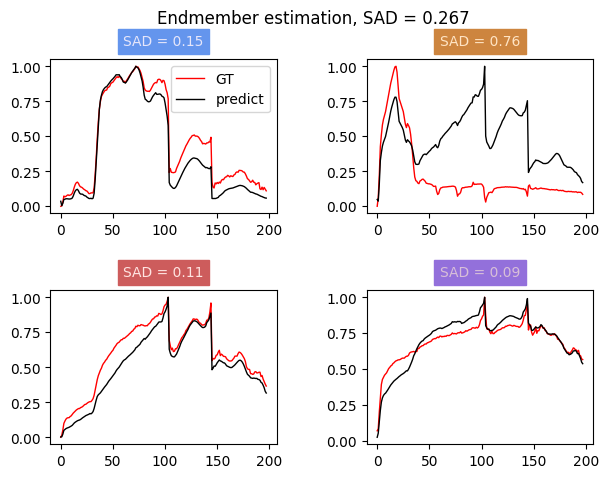

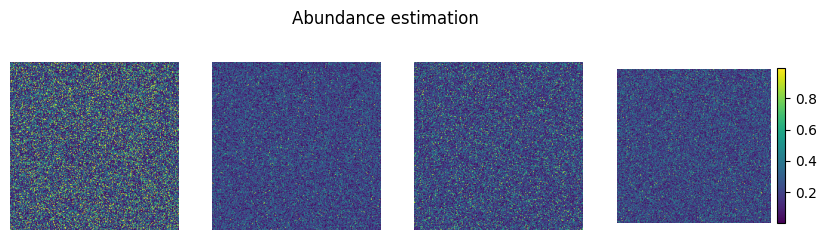

In [33]:
model = unmixer
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y/Y.max(), c, is_unmixer=True, use_sivm=True)

# for param in model.abundance_estimator.parameters():
#     param.requires_grad = False
    
print("The unmixer model has : ", format(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, '.2f'), "M trainable params")
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(name, ': ', format(param.numel()/1e3, '.2f'), "k params")

E_hat, A_hat, Y_hat = model(features)
utils.plot_results(E_hat, A_hat, E_gt=E, normalize_E=True)

In [34]:
# state_dict = model.decoder.state_dict()
# E_hat = model.decoder.get_endmembers()
# E_hat = utils.normalize(E_hat, dim=1)
# state_dict["decoder.weight"][:, :, 0, 0] = E_hat
# model.decoder.load_state_dict(state_dict)
# for param in model.decoder.parameters():
#     param.requires_grad = False
# W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.5, 1e-4, 1e-3, 1e-7, 1e-3#0.5, 1e-7, 1e-2, 1e-7, 0

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Epoch 0: total = 1.075, SAD = 0.481, MSE = 0.000, Ab = 0.230, TV_E = 0.183, TV_A = 0.008, Norm_E = 0.172
Epoch 20: total = 0.931, SAD = 0.351, MSE = 0.000, Ab = 0.221, TV_E = 0.182, TV_A = 0.007, Norm_E = 0.171
Epoch 40: total = 0.879, SAD = 0.305, MSE = 0.000, Ab = 0.216, TV_E = 0.183, TV_A = 0.006, Norm_E = 0.169
Epoch 60: total = 0.845, SAD = 0.274, MSE = 0.000, Ab = 0.214, TV_E = 0.183, TV_A = 0.006, Norm_E = 0.167
Epoch 80: total = 0.812, SAD = 0.246, MSE = 0.000, Ab = 0.213, TV_E = 0.183, TV_A = 0.006, Norm_E = 0.165
Epoch 100: total = 0.780, SAD = 0.219, MSE = 0.000, Ab = 0.212, TV_E = 0.181, TV_A = 0.006, Norm_E = 0.163
Epoch 120: total = 0.755, SAD = 0.199, MSE = 0.000, Ab = 0.211, TV_E = 0.178, TV_A = 0.006, Norm_E = 0.160
Epoch 140: total = 0.732, SAD = 0.182, MSE = 0.000, Ab = 0.210, TV_E = 0.176, TV_A = 0.005, Norm_E = 0.158
Epoch 160: total = 0.716, SAD = 0.171, MSE = 0.000, Ab 

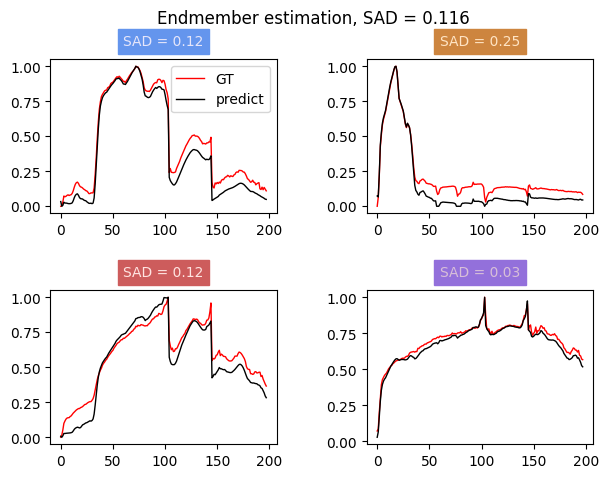

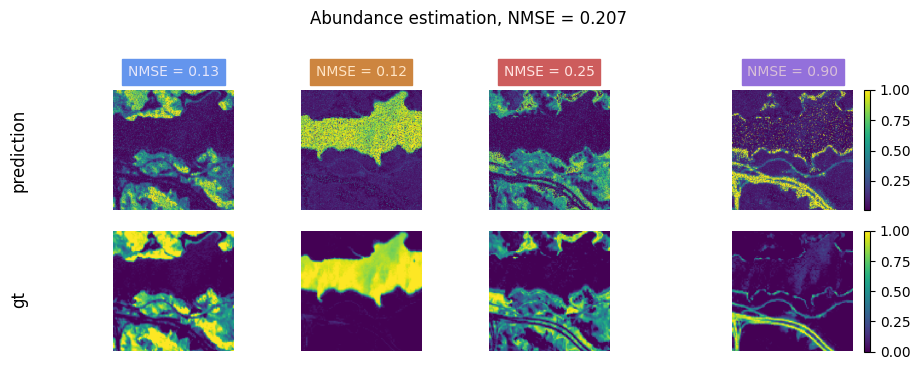

In [35]:
train_losses, sad_losses, ab_losses, tv_e_losses, tv_a_losses, mse_losses = [], [], [], [], [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

epochs, lr = 200, 0.001

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.05),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
optimizer = build_optim_wrapper(model, optim_wrapper)

for epoch in range(epochs):
    train_loss, sad_loss, ab_loss, tv_e_loss, tv_a_loss, mse_loss = 0, 0, 0, 0, 0, 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        if fm_name == "HyperSIGMA":
            E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, use_bn=True)
        
        elif fm_name == "DOFA" or fm_name == "HyperFree" or fm_name == "SpecViT":
            Y, A, features = rsfm.extract_f(fm_name, fm, Y, A, new_H, wavelengths, use_cls)
            E_hat, A_hat, Y_hat = model(features)

        else:
            pass
        
        Yn = utils.sum_to_one(Y)
        W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.5, 1e-4, 1e-3, 1e-7, 1e-3 #0.5, 0.2, 1e-2, 1e-7, 0
        loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e, hypersigma=False)
        # loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, hypersigma=True)
        train_loss += loss.item()
        sad_loss += loss_sad.item()
        ab_loss += loss_ab.item()
        tv_e_loss += loss_tv_e.item()
        tv_a_loss += loss_tv_a.item()
        mse_loss += loss_mse.item()

        if epoch%(epochs//10)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, MSE = {format(loss_mse, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV_E = {format(tv_e_loss, '.3f')}, TV_A = {format(loss_tv_a, '.3f')}, Norm_E = {format(loss_norm_e, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    sad_loss /= len(loader)
    ab_loss /= len(loader)
    tv_e_loss /= len(loader)
    tv_a_loss /= len(loader)
    mse_loss /= len(loader)
    train_losses.append(train_loss)
    sad_losses.append(sad_loss)
    ab_losses.append(ab_loss)
    tv_e_losses.append(tv_e_loss)
    tv_a_losses.append(tv_a_loss)
    mse_losses.append(mse_loss)

if fm_name == "DOFA" or fm_name == "HyperFree" or fm_name == "SpecViT":
    _, A, features = rsfm.extract_f(fm_name, fm, Y_init, A, new_H, wavelengths, use_cls)
    E_hat1, A_hat1, Y_hat1 = model(features)

else:
    new_H = H
    if Y_init.shape[-1] < new_H:
        Y_init = F.interpolate(Y_init, size=(new_H,new_H))
        A = F.interpolate(A, size=(new_H, new_H))
    E_hat1, A_hat1, Y_hat1 = rsfm.unmix_full_image_hypersigma(Y_init, model, fm, c, patch_size=patch_size, use_bn=True)

sad, mse = utils.plot_results(E_hat1, A_hat1, A, E, normalize_E=True, normalize_A=True, return_results=True, hypersigma=False)
# fig = utils.plot_losses(train_losses, sad_losses, ab_losses, tv_e_losses, mse_losses)

tensor(0.2617, device='cuda:0') tensor(0.1357, device='cuda:0', grad_fn=<DivBackward0>)


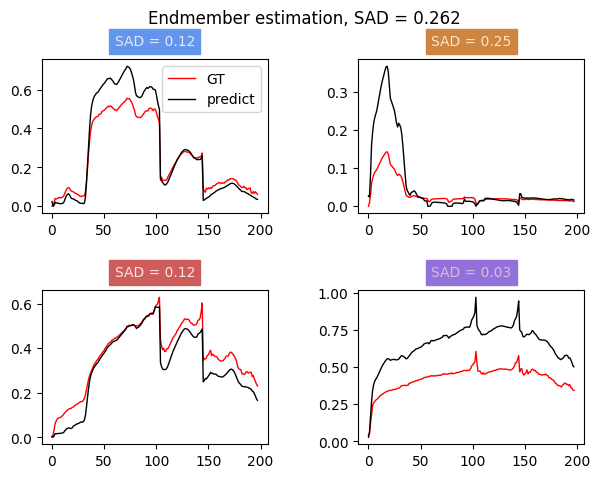

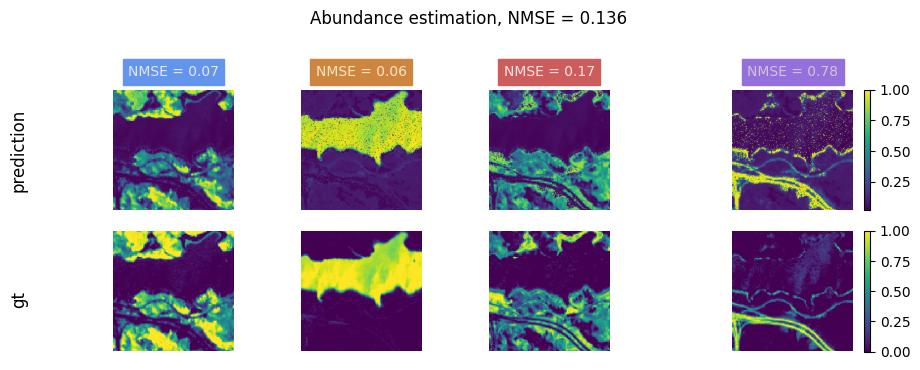

In [36]:
if fm_name == "DOFA" or fm_name == "HyperFree" or fm_name == "SpecViT":
    _, A, features = rsfm.extract_f(fm_name, fm, Y_init, A, new_H, wavelengths, use_cls)
    # model1.eval()
    # model2.eval()
    # E_hat1, A_hat1, Y_hat1 = model1(features)
    # E_hat2, A_hat2, Y_hat2 = model2(features)
    # E_hat = (E_hat1 + E_hat2)/2
    # A_hat = (A_hat1 + A_hat2)/2

    model.eval()
    E_hat, A_hat, Y_hat = model(features)

else:
    new_H = H
    if Y_init.shape[-1] < new_H:
        Y_init = F.interpolate(Y_init, size=(new_H,new_H))
        A = F.interpolate(A, size=(new_H, new_H))
    E_hat1, A_hat1, Y_hat1 = rsfm.unmix_full_image_hypersigma(Y_init, model, fm, c, patch_size=patch_size, use_bn=True)

# E_hat_vca = extractor.VCA(Y_init, c)
# E_hat_sivm = extractor.SiVM(Y_init, c)
sad, mse = utils.plot_results(E_hat, A_hat, A, E, normalize_E=False, normalize_A=True, return_results=True)
print(sad, mse)
# utils.plot_results(E_hat_vca, A_hat, E_gt=E, normalize_E=True)
# utils.plot_results(E_hat_sivm, A_hat, E_gt=E, normalize_E=True)
# E_hat, A_hat, _ = utils.order_endmembers(E, E_hat, A_hat)

In [52]:
class CNNAEU_with_decoder(nn.Module):
    def __init__(self, B, c, decoder=None, E_init=None):
        super().__init__()

        self.B = B
        self.c = c
        self.encoder = nn.Sequential(
            nn.Conv2d(self.B, 48, kernel_size=3, padding=1, padding_mode="reflect", bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(48),
            nn.Dropout2d(p=0.2),
            nn.Conv2d(48, self.c, kernel_size=1, bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(self.c),
            nn.Dropout2d(p=0.2),
        )
        if decoder != None:
            self.decoder = decoder
        else:
            self.decoder = rsfm.Decoder(self.c, self.B)
            if E_init != None:
                state_dict = self.decoder.state_dict()
                state_dict["decoder.weight"] = E_init.unsqueeze(-1).unsqueeze(-1)
                self.decoder.load_state_dict(state_dict)

        for param in self.decoder.parameters():
            param.requires_grad = False
    
    @staticmethod
    def loss(E_gt, E_hat, A_gt, A_hat, Y_gt, Y_hat):
        sad = utils.SADLoss()
        return sad(Y_gt, Y_hat)
    
    def forward(self, x):
        # Input shape (batch, B, N)
        
        if x.dim() < 3:
            x = x.unsqueeze(0) # Add a batch dimension for inference
        
        batch, B, N = x.shape
        x = utils.oneD_to_2d(x)
        
        code = self.encoder(x)
        
        abund = F.softmax(code, dim=1)
        a_hat = abund.reshape(batch, self.c, N)
        
        x_hat = self.decoder(abund)
        x_hat = x_hat.reshape(batch, B, N)
        
        e_hat = self.decoder.get_endmembers()
        
        return e_hat, a_hat, x_hat


sads_fm, mses_fm, sads_sivm, mses_sivm = [], [], [], []

sad = utils.SADLoss()
mse = nn.MSELoss(reduction="sum")

for n in range(25):
    E_init = extractor.SiVM(Y, c)
    # E_init = utils.normalize(E_init)
    cnnaeu_sivm = CNNAEU_with_decoder(B, c, E_init=E_init)
    cnnaeu_fm = CNNAEU_with_decoder(B, c, model.decoder)

    state_dict = cnnaeu_fm.decoder.state_dict()
    E_hat = model.decoder.get_endmembers()
    # E_hat = utils.normalize(E_hat, dim=1)
    state_dict["decoder.weight"] = E_hat.unsqueeze(-1).unsqueeze(-1)
    cnnaeu_fm.decoder.load_state_dict(state_dict)

    loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path="/home/edabier/Documents/Thèse/benchmark")

    epochs, lr = 100, 0.001
    optimizer_sivm = torch.optim.AdamW(cnnaeu_sivm.parameters(), lr=lr)
    optimizer_fm = torch.optim.AdamW(cnnaeu_fm.parameters(), lr=lr)

    for epoch in range(epochs):
        
        for Y_cnn, E_cnn, A_cnn in loader:
            optimizer.zero_grad()
            
            Y_cnn = Y_cnn.to(dev)
            Y_cnn = utils.oneD_to_2d(Y_cnn)
            # Y_cnn = utils.sum_to_one(Y_cnn)
            Y_cnn = Y_cnn/torch.max(Y_cnn)
            Y_cnn = Y_cnn.flatten(2)

            E_hat_cnn_sivm, A_hat_cnn_sivm, Y_hat_cnn_sivm = cnnaeu_sivm(Y_cnn)
            E_hat_cnn_fm, A_hat_cnn_fm, Y_hat_cnn_fm = cnnaeu_fm(Y_cnn)

            loss_sivm = cnnaeu_sivm.loss(E_cnn, E_hat_cnn_sivm, A_cnn, A_hat_cnn_sivm, Y_cnn, Y_hat_cnn_sivm)
            loss_fm = cnnaeu_fm.loss(E_cnn, E_hat_cnn_fm, A_cnn, A_hat_cnn_fm, Y_cnn, Y_hat_cnn_fm)
            
            loss_sivm.backward()
            optimizer_sivm.step()

            loss_fm.backward()
            optimizer_fm.step()
            break

    E_hat_cnn_fm, A_hat_cnn_fm, Y_hat_cnn_fm = cnnaeu_fm(Y.reshape(1, B, new_H**2))
    A_hat_cnn_fm = utils.oneD_to_2d(A_hat_cnn_fm)

    E_hat_cnn_sivm, A_hat_cnn_sivm, Y_hat_cnn_sivm = cnnaeu_sivm(Y.reshape(1, B, new_H**2))
    A_hat_cnn_sivm = utils.oneD_to_2d(A_hat_cnn_sivm)
    # utils.plot_results(E_hat_cnn_sivm, A_hat_cnn_sivm, A, E, model_name="SiVM", normalize_E=True, normalize_A=True, plot_E=False)
    # utils.plot_results(E_hat_cnn, A_hat_cnn, A, E, normalize_E=False, normalize_A=False)
    E_hat_cnn_fm, A_hat_cnn_fm, _ = utils.order_endmembers(E_cnn, E_hat_cnn_fm, A_hat_cnn_fm)
    E_hat_cnn_sivm, A_hat_cnn_sivm, _ = utils.order_endmembers(E_cnn, E_hat_cnn_sivm, A_hat_cnn_sivm)
    """Compute metrics"""
    # (c, H, W)
    A_hat_cnn_sivm_ = A_hat_cnn_sivm
    A_hat_cnn_fm_ = A_hat_cnn_fm
    A_ = A[0]

    # (c, H, W)
    A_sivm_norm = A_hat_cnn_sivm_/torch.norm(A_hat_cnn_sivm_)
    A_fm_norm = A_hat_cnn_fm_/torch.norm(A_hat_cnn_fm_)
    A_norm = A_/torch.norm(A_)

    # (H*W, c)
    A_hat_sivm_reshape = A_hat_cnn_sivm_.flatten(1).T
    A_hat_fm_reshape = A_hat_cnn_fm_.flatten(1).T
    A_reshape = A_.flatten(1).T

    sad_fm = sad(A_reshape, A_hat_fm_reshape).item()
    sad_sivm = sad(A_reshape, A_hat_sivm_reshape).item()
    mse_fm = (mse(A_norm, A_fm_norm)/(torch.norm(A_norm))).item()
    mse_sivm = (mse(A_norm, A_sivm_norm)/(torch.norm(A_norm))).item()
    sads_fm.append(sad_fm)
    mses_fm.append(mse_fm)
    sads_sivm.append(sad_sivm)
    mses_sivm.append(mse_sivm)
    print(f"{n+1} xp done")

print(f"FM: SAD = {format(torch.mean(torch.tensor(sads_fm)), ".3f")} ± {format(torch.std(torch.tensor(sads_fm)), ".2f")}, NMSE = {format(torch.mean(torch.tensor(mses_fm)), ".3f")} ± {format(torch.std(torch.tensor(mses_fm)), ".2f")}")
print(f"SiVM: SAD = {format(torch.mean(torch.tensor(sads_sivm)), ".3f")} ± {format(torch.std(torch.tensor(sads_sivm)), ".2f")}, NMSE = {format(torch.mean(torch.tensor(mses_sivm)), ".3f")} ± {format(torch.std(torch.tensor(mses_sivm)), ".2f")}")

1 xp done
2 xp done
3 xp done
4 xp done
5 xp done
6 xp done
7 xp done
8 xp done
9 xp done
10 xp done
11 xp done
12 xp done
13 xp done
14 xp done
15 xp done
16 xp done
17 xp done
18 xp done
19 xp done
20 xp done
21 xp done
22 xp done
23 xp done
24 xp done
25 xp done
FM: SAD = 0.374 ± 0.11, NMSE = 0.205 ± 0.12
SiVM: SAD = 0.427 ± 0.17, NMSE = 0.270 ± 0.17


In [38]:
# (c, H, W)
A_hat_cnn_sivm_ = A_hat_cnn_sivm[0]
A_hat_cnn_fm_ = A_hat_cnn_fm[0]
A_ = A[0]

# (c, H, W)
A_sivm_norm = A_hat_cnn_sivm_/torch.norm(A_hat_cnn_sivm_)
A_fm_norm = A_hat_cnn_fm_/torch.norm(A_hat_cnn_fm_)
A_norm = A_/torch.norm(A_)

# (H*W, c)
A_hat_sivm_reshape = A_hat_cnn_sivm_.flatten(1).T
A_hat_fm_reshape = A_hat_cnn_fm_.flatten(1).T
A_reshape = A_.flatten(1).T

sad_fm = sad(A_reshape, A_hat_fm_reshape).item()
sad_sivm = sad(A_reshape, A_hat_sivm_reshape).item()
mse_fm = (mse(A_norm, A_fm_norm)/(torch.norm(A_norm))).item()
mse_sivm = (mse(A_norm, A_sivm_norm)/(torch.norm(A_norm))).item()
print(sad_fm, sad_sivm, mse_fm, mse_sivm)

1.2389589548110962 1.3208602666854858 1.5395312309265137 1.6382700204849243


<Figure size 640x480 with 0 Axes>

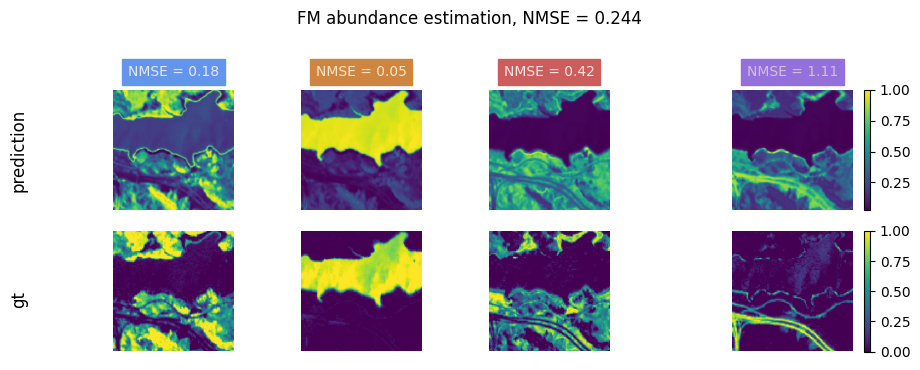

In [43]:
utils.plot_results(E_hat_cnn_fm, A_hat_cnn_fm, A, E, model_name="FM", normalize_E=True, normalize_A=True, plot_E=False)

<Figure size 640x480 with 0 Axes>

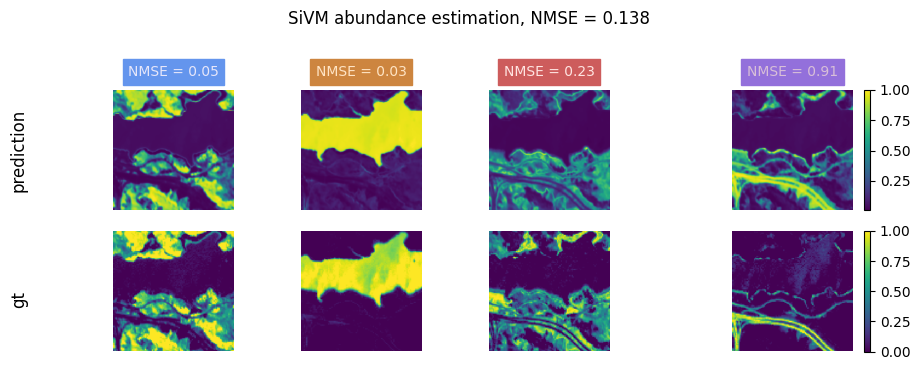

In [44]:
utils.plot_results(E_hat_cnn_sivm, A_hat_cnn_sivm, A, E, model_name="SiVM", normalize_E=True, normalize_A=True, plot_E=False)

In [16]:
sad = utils.SADLoss()
mse = nn.MSELoss(reduction="sum")

# (c, H, W)
A_hat_cnn_sivm_ = A_hat_cnn_sivm[0]
A_hat_cnn_fm_ = A_hat_cnn_fm[0]
A_ = A[0]

# (c, H, W)
A_sivm_norm = A_hat_cnn_sivm_/torch.norm(A_hat_cnn_sivm_)
A_fm_norm = A_hat_cnn_fm_/torch.norm(A_hat_cnn_fm_)
A_norm = A_/torch.norm(A_)

# (H*W, c)
A_hat_sivm_reshape = A_hat_cnn_sivm_.flatten(1).T
A_hat_fm_reshape = A_hat_cnn_fm_.flatten(1).T
A_reshape = A_.flatten(1).T

print(f"FM: {sad(A_reshape, A_hat_fm_reshape).item()}, {(mse(A_norm, A_fm_norm)/(torch.norm(A_norm)**2)).item()}")
print(f"SiVM: {sad(A_reshape, A_hat_sivm_reshape).item()}, {(mse(A_norm, A_sivm_norm)/(torch.norm(A_norm)**2)).item()}")

FM: 1.125738263130188, 1.3383089303970337
SiVM: 1.2073806524276733, 1.5183448791503906


In [ ]:
diff = A_hat - A_hat2
mean = (A_hat + A_hat2)/2
plt.imshow(A_hat[0].detach().cpu())

A_hat2 = torch.stack([A_hat2[0, 1], A_hat2[0, 2], A_hat2[0, 0], A_hat2[0, 3]], dim=0)
utils.compare_hsis(A_hat, A_hat2)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT")
import models_mae_spectral

torch.serialization.add_safe_globals([argparse.Namespace])
state_dict = torch.load("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT/data/SpectralGPT+.pth", map_location=dev)["model"]

img_size = 128
spectral_gpt = models_mae_spectral.mae_vit_base_patch8_128(num_frames=Y.shape[0], pred_t_dim=Y.shape[0])
# spectral_gpt = models_mae_spectral.__dict__[f"mae_vit_base_patch{patch_size}_{img_size}"]()

encoder_keys = [k for k in state_dict.keys() if k.startswith('patch_embed') or k.startswith('blocks') or k.startswith('norm')]
encoder_state_dict = {k: state_dict[k] for k in encoder_keys}
spectral_gpt.load_state_dict(encoder_state_dict, strict=False)

y_patch = Y.unsqueeze(0)[:,:,:img_size,:img_size]
# y_patch = y_patch.reshape(Y.shape[0], 1, img_size, img_size)
# print(y_patch.shape)
# y_patch = y_patch.reshape(y_patch.shape[0], y_patch[2], y_patch[1], y_patch[3])
latent, _, _ = spectral_gpt.forward_encoder(y_patch, mask_ratio=0.0)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/HyperFree")
from HyperFree import build_HyperFree_vit_b, predictor

pred = build_HyperFree_vit_b(checkpoint="/home/ids/edabier/HSU/HyperFree/data/HyperFree-b.pth", image_size=batched_Y.shape[2], vit_patch_size=patch_size)
hyperfree = predictor.HyperFree_Predictor(pred)

input_y = hyperfree.transform.apply_image_torch(batched_Y)
hyperfree.set_torch_image(input_y, original_image_size=(Y.shape[1], Y.shape[2]), spectral_lengths=wavelengths, GSD=GSD)
hyperfree.features.shape